# Geospatial demand estimation

**Original code:** [Alexandros Korkovelos](https://github.com/akorkovelos) <br />
**Support:** [Ariane Millot](https://github.com/ariane-millot), [Martin J. Stringer]()<br />
**Funding:** Imperial College <br />

---------------------------


#### Brief overview

This notebook performs three main analytical processes:

- **Part 1**: Generated grid mesh (H3 hexagons) for the area of interest (given input admin boundary)
- **Part 2**: Extract GIS-based attributes (vecror or raster) to the grid
- **Part 3**: Build blocks estimating demand for the different energy vectors

A slightly more detailed description of the processing bits is presented before each part below. <br />


In [1]:
# Decide if you want to run a region or the country
area = "COUNTRY"
# area = "Copperbelt" # Regions = Central, Copperbelt, Eastern

### Import necessary modules

In [50]:
### Activate geospatial_env first

# Numeric
import numpy as np
import pandas as pd
import math

# System
import os
import shutil
from IPython.display import display, Markdown, HTML, FileLink, FileLinks

# Spatial
import geopandas as gpd
import json
import pyproj
from shapely.geometry import Point, Polygon, MultiPoint
from shapely.geometry import shape, mapping
from shapely.ops import unary_union
from shapely.geometry.polygon import Polygon
from shapely.wkt import dumps, loads
from shapely.ops import nearest_points
from pyproj import CRS
#from osgeo import ogr, gdal, osr
import fiona
from rasterstats import zonal_stats
import rasterio
import rasterio.fill
#from geojson import Feature, Point, FeatureCollection
import h3 as h3

# Mapping / Plotting
from functools import reduce
#import datapane as dp 
#!datapane login --token="9bde41bfbc4ad14119e32086f9f06d2e5db1d5b8"
import folium
from folium.features import GeoJsonTooltip
from folium.plugins import BeautifyIcon
from folium.plugins import HeatMap
import branca.colormap as cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as colors
from matplotlib.ticker import MaxNLocator
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib import font_manager
%matplotlib inline

In [51]:
# import ipywidgets as widgets
import tkinter as tk
from tkinter import filedialog, messagebox
import datetime
import warnings
import scipy.spatial
warnings.filterwarnings('ignore')

#import seaborn as sns

root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)

pd.options.display.float_format = '{:,.2f}'.format

In [4]:
from utils import processing_raster, finalizing_rasters, spatialjoinvectors

### Define directories and dataset names

In [5]:
os.path.abspath(os.curdir)

'c:\\Users\\rheredia\\OneDrive - Imperial College London\\UKPACT\\EDeMOS_Malawi'

In [6]:
### Define directories and dataset names
ROOT_DIR = os.path.abspath(os.curdir)
in_path = ROOT_DIR
out_path = ROOT_DIR + "/Outputs/"

In [7]:
## Coordinate and projection systems
crs_WGS84 = CRS("EPSG:4326")    # Originan WGS84 coordinate system
crs_proj = CRS("EPSG:32736")    # Projection system for the selected country -- see http://epsg.io/ for more info

# Part 1. Create base grid with H3

COUNTRY
EPSG:4326
Missing regions: set()


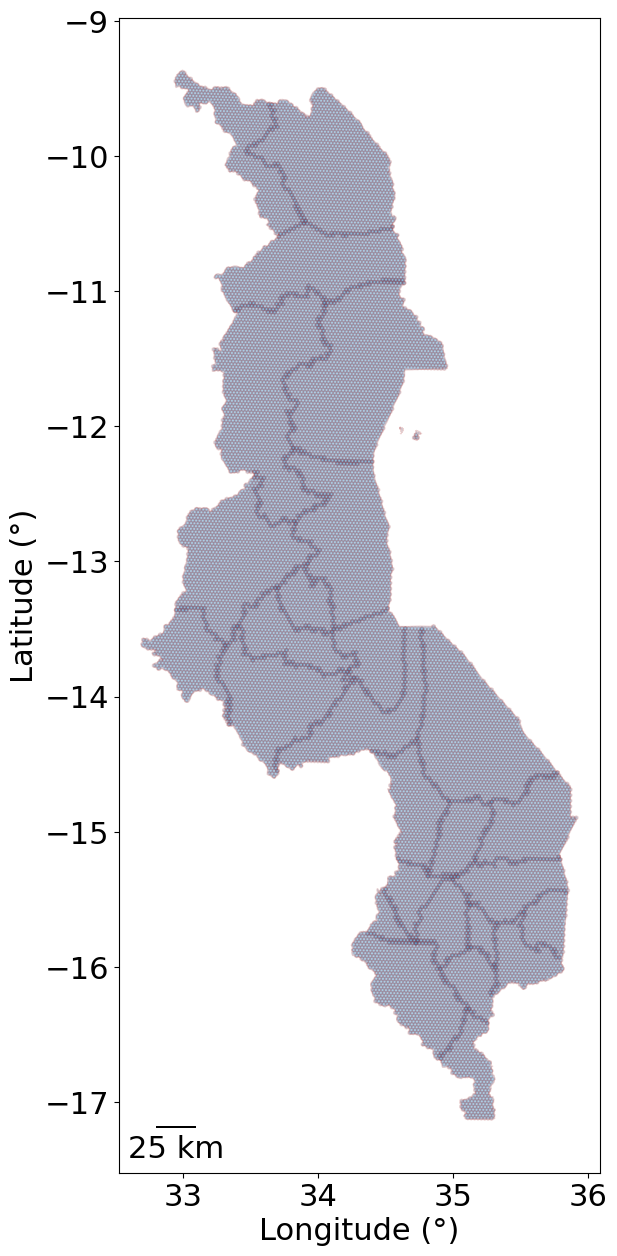

<Figure size 640x480 with 0 Axes>

In [8]:
%run BaseGridHex.ipynb

# Part 2. Extract GIS-based attributes

## Extract raster values to hexagons

##### Once done with rasters run this cell

In [9]:
#grid = finalizing_rasters(out_path, grid, crs_proj)

Final dataframe

In [10]:
# grid.drop(['index_right'], axis=1, inplace=True)
# grid.head(4)

## Extract information from vector layers

In [8]:
## admininstrative boundary
admin_path = os.path.join(in_path, 'admin')
admin_name = "gadm41_MWI.gpkg"      
region_col_name = "NAME_1"   ## Provide the name of the column you want to use to clip the hexagons e.g., "NAME" or "ADM1_NAME"
layer_region_name = "ADM_ADM_1"
layer_admin_name = "ADM_ADM_0"
if area == "COUNTRY":
    admin_gdf = gpd.read_file(admin_path + "/" + admin_name, layer=layer_admin_name)
    region_gdf = gpd.read_file(admin_path + "/" + admin_name, layer=layer_region_name)

In [9]:
#extract_region
region_gdf['NAME_1'].to_csv("./admin/Regions_list.csv", index=False)

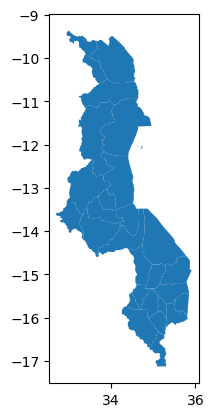

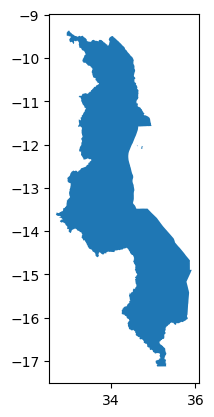

In [10]:
region_gdf.plot(), admin_gdf.plot()
plt.show()

In [13]:
# transmission lines  

#https://energydata.info/dataset/kenya-kenya-electricity-network

# 220KV

lines_gdf = gpd.read_file(ROOT_DIR + "/Grid/Transmission lines 220kV/220kV.shp")

if lines_gdf.crs != crs_WGS84:
    lines_gdf = lines_gdf.to_crs(crs_WGS84)

lines_gdf = gpd.clip(lines_gdf, admin_gdf)

In [14]:
#132kV

lines_132 = gpd.read_file(ROOT_DIR + "/Grid/Transmission lines 132kV/132kV.shp")

if lines_132.crs != crs_WGS84:
    lines_132 = lines_132.to_crs(crs_WGS84)

lines_132 = gpd.clip(lines_132, admin_gdf)

# Part 3. Constructing Multi-vector Demand

### Calculate Total Demand

**Demand = Residential + Commercial + Industrial **

where, 

**Residential** = No of HH with access X average en. cons. kWh/HH/year

**Commercial**  = Number of employee X average en. con. kWh/employee

**Industrial**  = Commodity Production (tonnes) from mines X average energy consumption per tonne

In [16]:
currentdir = os.path.abspath(os.getcwd())
os.path.basename(currentdir)

'UKPACT'

2025-04-30 18:28:32.567103
2025-04-30 18:29:25.947967
2025-04-30 18:30:31.437156
2025-04-30 18:31:24.116487
2025-04-30 18:32:31.342581
2025-04-30 18:33:36.992751
2025-04-30 18:34:47.198686
2025-04-30 18:34:52.312722
-1.1169999837875366
1.4839999675750732
Residential electricity consumption UN stats 572.3000000000001 GWh
services electricity consumption UN STATS: 296 GWh


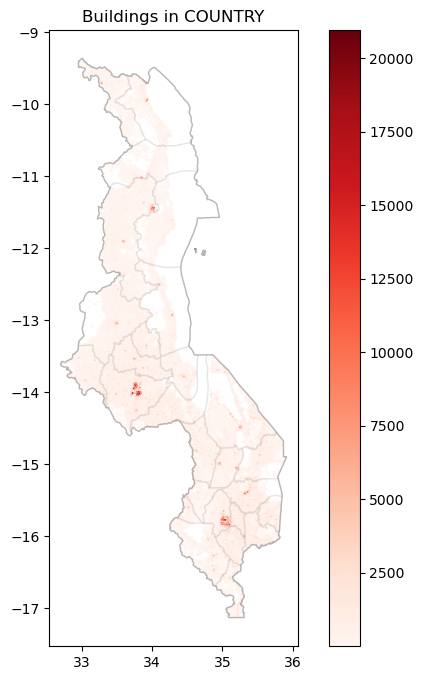

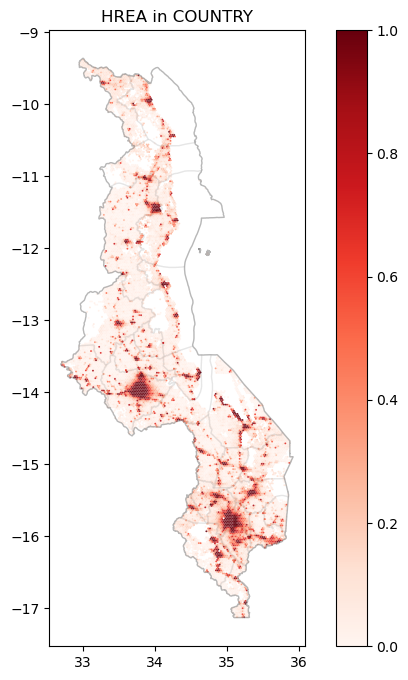

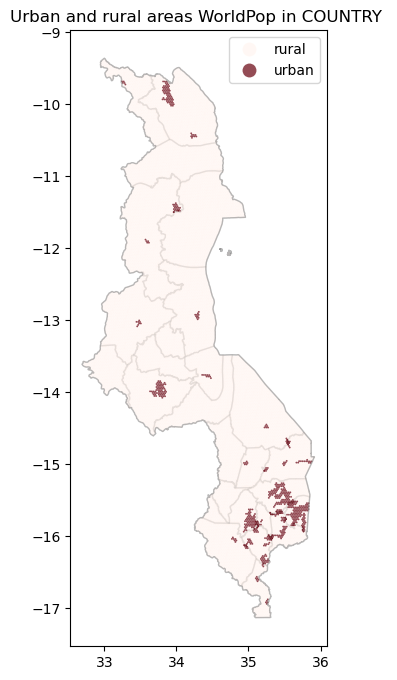

Status_electrified
nonelec    15776
elec        5091
Name: count, dtype: int64
Total population: 17,417,235
Total population: 17,417,235
Total population with access: 5,045,908
Pop access rate : 29%
Pop access rate urban: 74%
Pop access rate rural: 21%


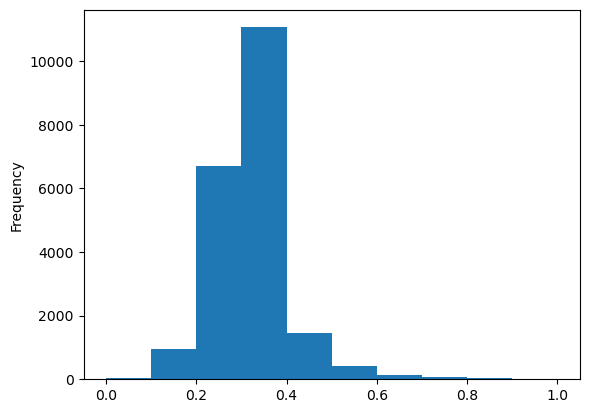

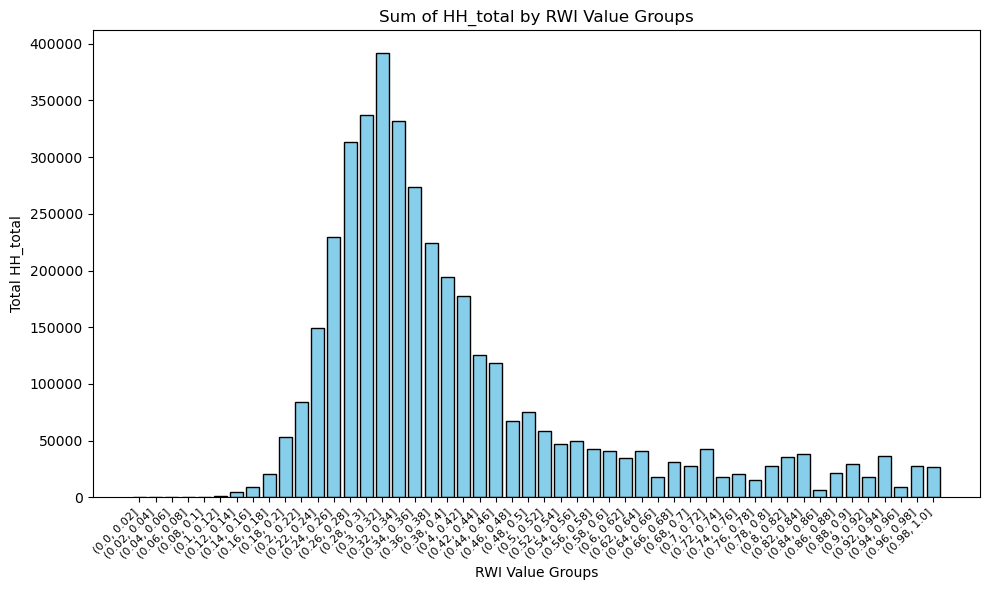

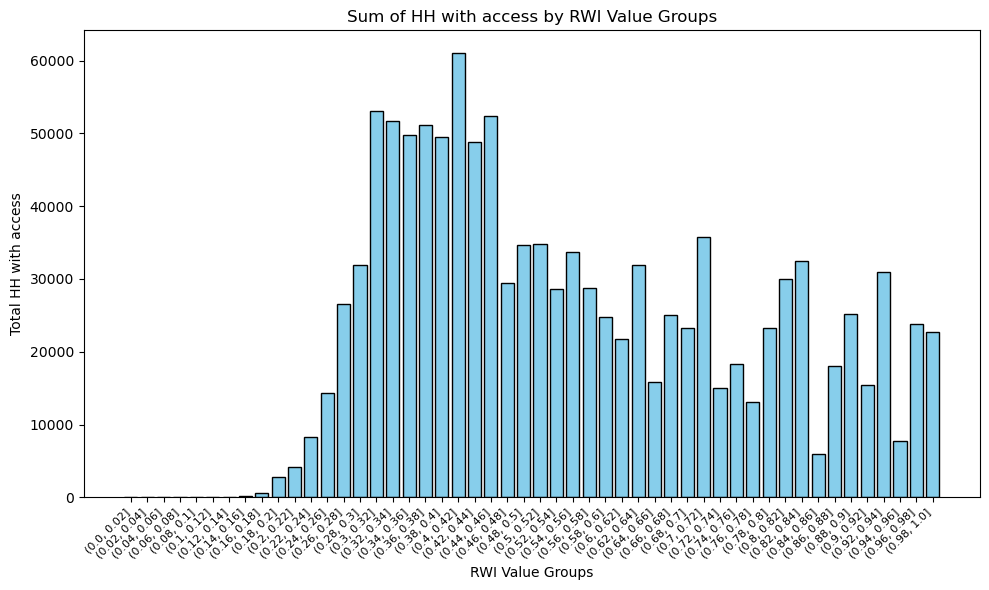

[15.74192994]


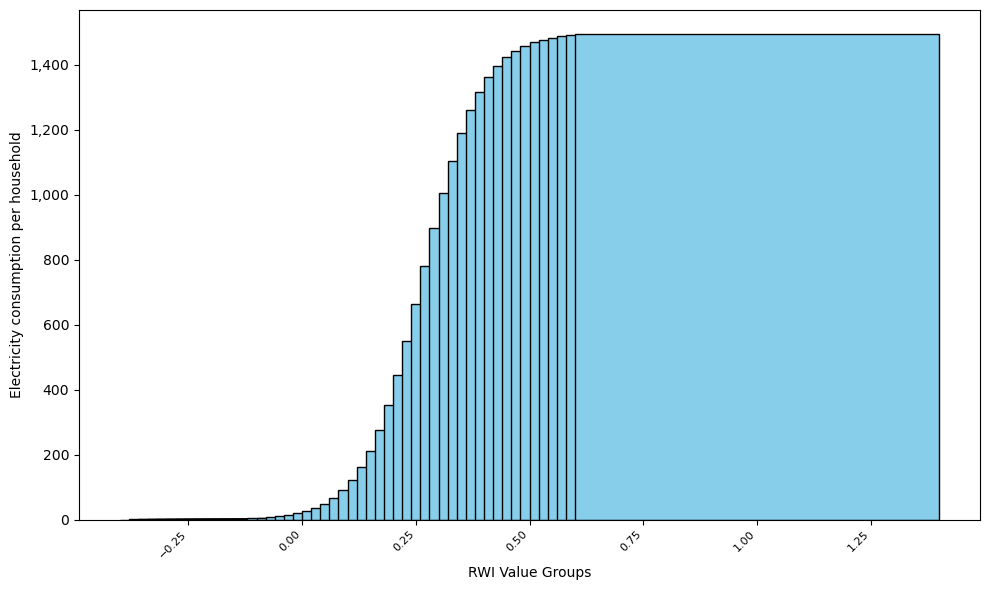

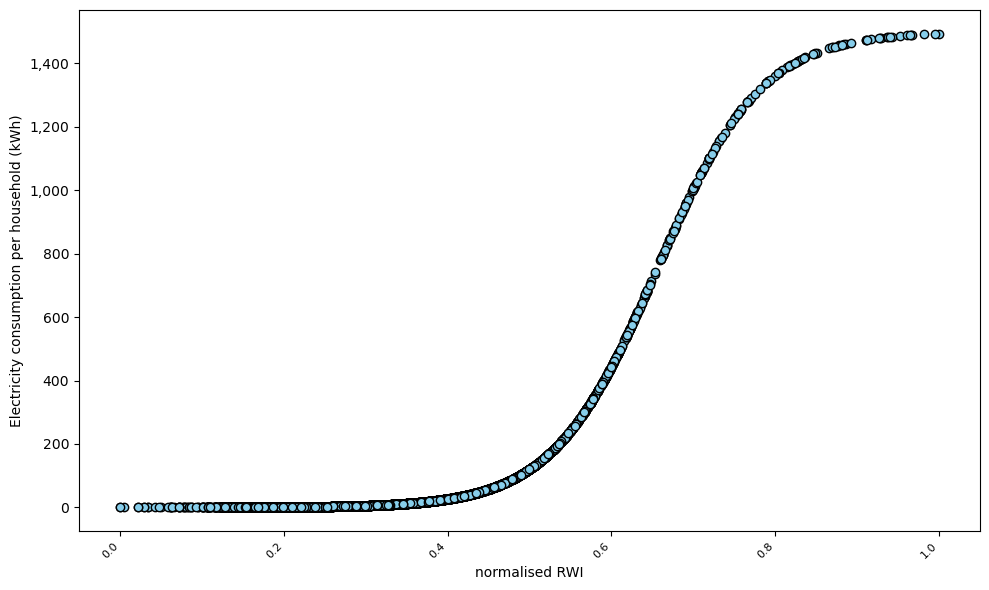

urban total = 87 GWh/year
urban average per houshold = 191 kWh/year
urban min = 0 kWh/year max = 347 kWh/year
Created rwi_vs_energy_use_urban.png


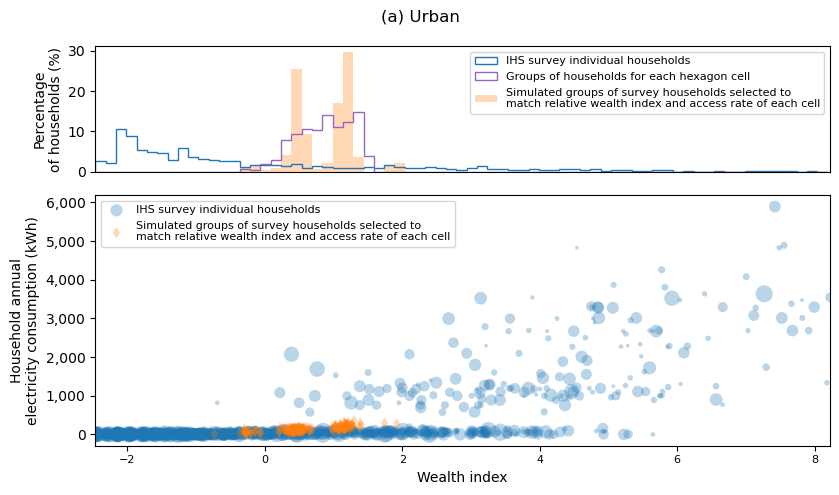

rural total = 2 GWh/year
rural average per houshold = 2 kWh/year
rural min = 0 kWh/year max = 2 kWh/year
Created rwi_vs_energy_use_rural.png


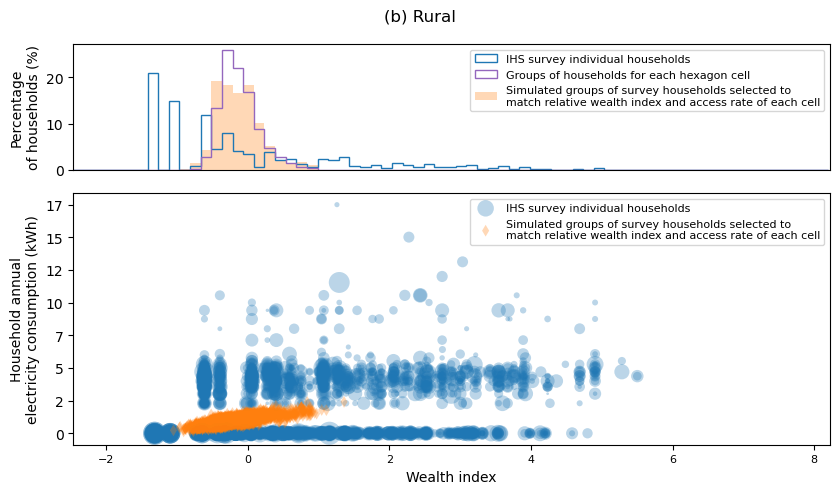

             national  urban  rural
tiers_meth1                        
0                0.74   0.25   0.83
1                0.10   0.02   0.11
2                0.05   0.08   0.04
3                0.05   0.24   0.02
4                0.06   0.41   0.00
5                0.00   0.00   0.00
             national  urban  rural
tiers_meth2                        
0                0.88   0.25   1.00
1                0.01   0.04   0.00
2                0.11   0.71   0.00
3                0.00   0.00   0.00
4                0.00   0.00   0.00
5                0.00   0.00   0.00
Number of lines with similar values: 20507
Mean difference: 0.04145301193271673
Median difference: 0.0
Mode difference: 0   0.00
Name: Difference, dtype: float64
Index(['h3_index', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'index', 'index_righ',
       'NAME_1', 'id', 'buildingssum', 'locationWP', 'HREA', 'rwi',
       'tiers_falchetta_maj', 'tiers_falchetta_mean', 'GDP_PPP', 'geometry',
       'locWorldPop', 'location', 'Stat

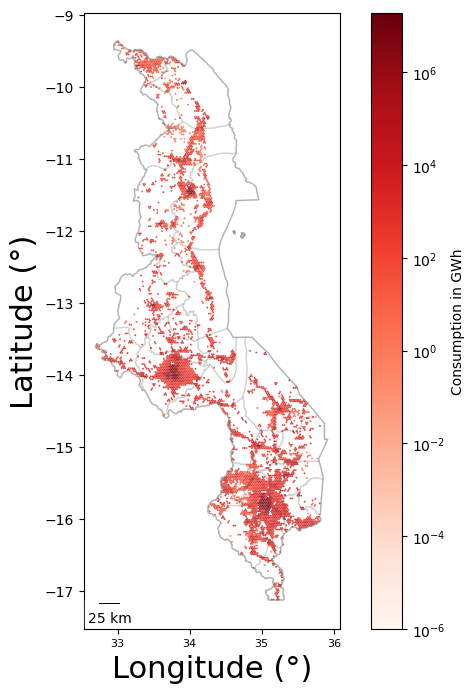

4,425,800 services buildings
total services buildings with access: 1,515,305
195 kWh per building
total GDP (k$): 4,216,235
70 kWh per unit of GDP (k$)
True
Index(['Balaka', 'Blantyre', 'Chikwawa', 'Chiradzulu', 'Chitipa', 'Dedza',
       'Dowa', 'Karonga', 'Kasungu', 'Likoma', 'Lilongwe', 'Machinga',
       'Mangochi', 'Mchinji', 'Mulanje', 'Mwanza', 'Mzimba', 'Neno',
       'Nkhata Bay', 'Nkhotakota', 'Nsanje', 'Ntcheu', 'Ntchisi', 'Phalombe',
       'Rumphi', 'Salima', 'Thyolo', 'Zomba'],
      dtype='object', name='region')
Total number of women: 1,108,517
Total number of men: 967,967
nb of working women 5,332
nb of total employee 9,409
nb of total employee with access 4,468
66,141 kWh per employee


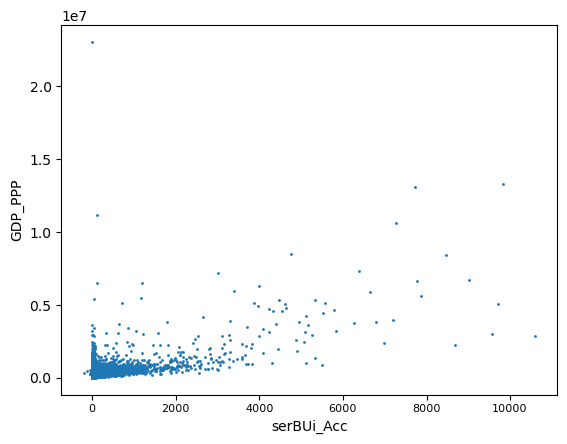

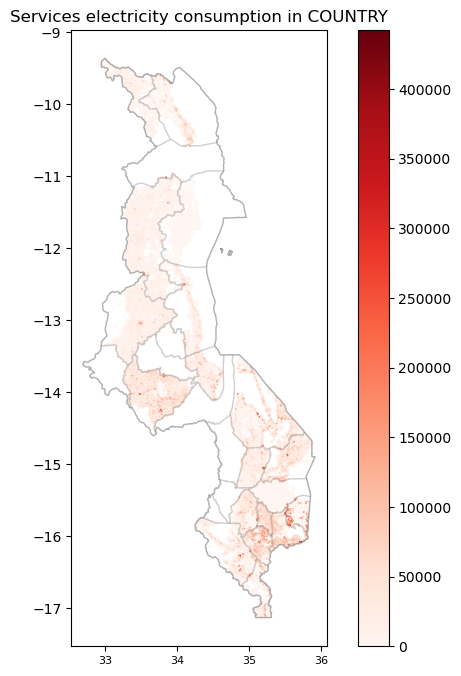

Services electricity consumption assessed after scaling:
Balaka 11.5 GWh
Blantyre 13.0 GWh
Chikwawa 15.5 GWh
Chiradzulu 10.2 GWh
Chitipa 6.1 GWh
Dedza 0.0 GWh
Dowa 0.0 GWh
Karonga 9.1 GWh
Kasungu 21.7 GWh
Likoma 0.0 GWh
Lilongwe 47.6 GWh
Machinga 20.8 GWh
Mangochi 31.2 GWh
Mchinji 0.0 GWh
Mulanje 19.5 GWh
Mwanza 0.0 GWh
Mzimba 25.9 GWh
Neno 0.0 GWh
Nkhata Bay 0.0 GWh
Nkhotakota 10.2 GWh
Nsanje 8.1 GWh
Ntcheu 0.0 GWh
Ntchisi 0.0 GWh
Phalombe 12.1 GWh
Rumphi 0.0 GWh
Salima 12.7 GWh
Thyolo 20.3 GWh
Zomba 0.0 GWh
NAME_1
Balaka       11.45
Blantyre     13.02
Chikwawa     15.51
Chiradzulu   10.17
Chitipa       6.14
Dedza         0.00
Dowa          0.00
Karonga       9.09
Kasungu      21.70
Likoma        0.00
Lilongwe     47.63
Machinga     20.78
Mangochi     31.20
Mchinji       0.00
Mulanje      19.50
Mwanza        0.00
Mzimba       25.88
Neno          0.00
Nkhata Bay    0.00
Nkhotakota   10.18
Nsanje        8.07
Ntcheu        0.00
Ntchisi       0.00
Phalombe     12.12
Rumphi        0.00
Sal

In [12]:
%run Residential/building_demand.ipynb

In [13]:
total_residentialenergy_assessed = grid['ResEnergy_kWh_meth2'].sum()
print("residential electricity consumption:", f"{total_residentialenergy_assessed/10**6:,.0f}","GWh") # GWh

residential electricity consumption: 75 GWh


In [44]:
#%run Industry/IndustryDemand.ipynb
#print("Industry electricity consumption in",f"{area}",f"{total_industryenergy/3600:,.1f}", "TWh")

In [14]:
# Concatenate results
out_path = ROOT_DIR + "/Outputs/"
gridBui = gpd.read_file(out_path + "ser_energy_map.geojson") # contains services and residential data
#gridInd = gpd.read_file(out_path + "ind_energy_map.geojson")

grid = gridBui.copy()
#grid = grid.merge(gridInd, on='id', suffixes=('', '_y'))
grid.drop(grid.filter(regex='_y$').columns, axis=1, inplace=True)
grid.head(4)

,h3_index,n0,n1,n2,n3,n4,n5,index,index_righ,NAME_1,...,nb_women,nb_men,nb_women_working,nb_men_working,total_employee,total_employee_withaccess,SEn_kWh_Emp,SEn_kWh_weighted,SEn_kWh_final,geometry
0,8797ae26effffff,14122,18671,2728,11263,18948,12448,0,27,Zomba,...,77.11,65.39,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"POLYGON ((35.60452 -15.41667, 35.59199 -15.423..."
1,87978dbb0ffffff,7593,13868,7556,500,11308,12990,1,10,Lilongwe,...,120.49,107.49,0.62,0.52,1.14,1.14,75512.35,75512.35,48554.94,"POLYGON ((33.75333 -13.74716, 33.74077 -13.753..."
2,8797ad5a4ffffff,9441,1510,18205,18466,18751,14301,2,2,Chikwawa,...,24.40,21.62,0.13,0.10,0.23,0.23,15266.67,15266.67,9816.57,"POLYGON ((34.93569 -16.31472, 34.92308 -16.321..."
3,8797ad4edffffff,7405,1328,13048,148,7776,12603,3,2,Chikwawa,...,1.19,1.05,0.01,0.00,0.01,0.00,742.70,742.70,477.56,"POLYGON ((34.59294 -16.14096, 34.58031 -16.147..."


In [15]:
# Units
#grid["IndEnergy_GWh"]=grid["IndEne_TJ"]/3600 *10**3
#grid['IndEnergy_kWh'] = grid['IndEnergy_GWh'] * 10**6
#total_ind = grid["IndEnergy_GWh"].sum()
#print(f"Industry: {total_ind:,.0f}", "GWh")
grid['REnS_kWh'] = grid['ResEnergy_kWh_meth2_scaled']
grid['REnS_GWh'] = grid['REnS_kWh'] / 10**6
total_res = grid["REnS_GWh"].sum()
print(f"Residential: {total_res:,.0f}", "GWh")
grid['SEn_GWh'] = grid['SEn_kWh_final'] / 10**6
grid['SEn_kWh'] = grid['SEn_GWh'] * 10**6
total_ser = grid["SEn_GWh"].sum()
print(f"Services: {total_ser:,.0f}", "GWh")

Residential: 572 GWh
Services: 296 GWh


In [16]:
grid["TotalDem_GWh"] = grid.apply(lambda row: (np.nansum([row['REnS_GWh'], 
                                          row['SEn_GWh'],  
                                                ])), axis=1) #sum in GWh
grid["TotalDem_kWh"]= grid['TotalDem_GWh'] * 10**6
total = grid["TotalDem_GWh"].sum()
print("total electricity consumption:", f"{total:,.0f}","GWh") # GWh

total electricity consumption: 868 GWh


In [17]:
grid.head(3)

,h3_index,n0,n1,n2,n3,n4,n5,index,index_righ,NAME_1,...,SEn_kWh_Emp,SEn_kWh_weighted,SEn_kWh_final,geometry,REnS_kWh,REnS_GWh,SEn_GWh,SEn_kWh,TotalDem_GWh,TotalDem_kWh
0,8797ae26effffff,14122,18671,2728,11263,18948,12448,0,27,Zomba,...,0.00,0.00,0.00,"POLYGON ((35.60452 -15.41667, 35.59199 -15.423...",0.00,0.00,0.00,0.00,0.00,0.00
1,87978dbb0ffffff,7593,13868,7556,500,11308,12990,1,10,Lilongwe,...,75512.35,75512.35,48554.94,"POLYGON ((33.75333 -13.74716, 33.74077 -13.753...",378.99,0.00,0.05,48554.94,0.05,48933.93
2,8797ad5a4ffffff,9441,1510,18205,18466,18751,14301,2,2,Chikwawa,...,15266.67,15266.67,9816.57,"POLYGON ((34.93569 -16.31472, 34.92308 -16.321...",53.04,0.00,0.01,9816.57,0.01,9869.61


In [18]:
#Grouped results
res_SEn = grid[['NAME_1','location', 'ResEnergy_kWh_meth2_scaled', 'SEn_kWh_final','TotalDem_kWh']].copy()
res_SEn_grouped = res_SEn.groupby(['NAME_1', 'location']).sum().reset_index()

print(res_SEn_grouped)
res_SEn_grouped.to_csv(out_path + "\\" + "res_SEn_grouped.csv")

        NAME_1 location  ResEnergy_kWh_meth2_scaled  SEn_kWh_final  \
0       Balaka    rural                   153996.78    11137413.38   
1       Balaka    urban                  8301804.47      314373.42   
2     Blantyre    rural                   447710.30    13018162.47   
3     Blantyre    urban                207819316.90           0.00   
4     Chikwawa    rural                   292625.89    15430159.65   
5     Chikwawa    urban                   771555.56       83342.49   
6   Chiradzulu    rural                   325227.13    10170060.34   
7   Chiradzulu    urban                   487610.60           0.00   
8      Chitipa    rural                    34513.46     6031161.65   
9      Chitipa    urban                   565100.59      112213.59   
10       Dedza    rural                   223827.99           0.00   
11        Dowa    rural                   218470.92           0.00   
12     Karonga    rural                    77210.46     8692735.26   
13     Karonga    ur

### Export result

In [19]:
crs_WGS84 = CRS("EPSG:4326")    # Originan WGS84 coordinate system
grid = grid.to_crs({ 'init': crs_WGS84}) 

In [20]:
with fiona.Env(OSR_WKT_FORMAT="WKT2_2018"):
    grid.to_file(out_path + 'total_demand_grid.gpkg', driver="GPKG", index=False, engine='fiona')
#grid.to_file(out_path + 'total_demand_grid.geojson', driver="GeoJSON")
grid.to_file(out_path + f'total_demand.geojson', driver='GeoJSON', index=False)  

## Print maps for quick assessment

In [21]:
plt.rcParams.update({'font.size': 22})

### Total demand map

In [53]:
# # Plot the demand map with use of the full scale
# # Create the axis first
# fig, ax = plt.subplots(figsize=(10, 15))

# # Plot data
# grid.sort_values('TotalDem_GWh', ascending=True).plot(
#     ax=ax, column='TotalDem_GWh', cmap="Reds", legend=True, alpha=0.5)

# ax.set_aspect('equal', 'box')
# txt = ax.set_title('Electricity in {} (kWh)'.format(area) )

# # Save plot as figure 
# plt.savefig(out_path +'total_elec_demand_map.png', bbox_inches='tight')

In [54]:
# # Plot the demand map with a threshold value
# # Create the axis first
# # fig, ax = plt.subplots(figsize=(25, 15))
# fig, ax = plt.subplots(figsize=(15, 10))

# # Set the threshold
# # threshold = np.percentile(npgrid['TotalDem'], 90)
# threshold = 0.1 * grid['TotalDemGWh'].max()

# # Plot data
# grid.sort_values('TotalDem_GWh', ascending=True).plot(
#     ax=ax, column='TotalDem_GWh', cmap="Reds", legend=True, alpha=0.5, vmin=0, vmax=threshold)

# ax.set_aspect('equal', 'box')
# txt = ax.set_title('Electricity in {} (kWh)'.format(area) )

# # Save plot as figure 
# plt.savefig(out_path +'total_demand_elec_map_threshold.png', bbox_inches='tight')

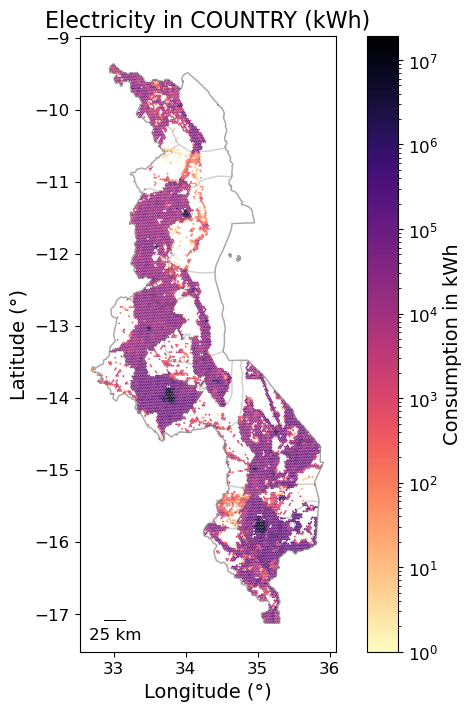

In [79]:
# Plot the demand map with a log scale value
# Create the axis first
fig, ax = plt.subplots(figsize=(8, 8))
# Add latitude and longitude labels
ax.set_xlabel('Longitude (°)', fontsize=14)
ax.set_ylabel('Latitude (°)', fontsize=14)
ax.tick_params(axis='both', labelsize=12)


# Plot data
grid.sort_values('TotalDem_kWh', ascending=True).plot(ax=ax,
                column='TotalDem_kWh', cmap="magma_r", legend=True,
                 alpha=1, norm=colors.LogNorm(vmin = 1, vmax=grid['TotalDem_kWh'].max()))
#legend
legend = fig.axes[1] 
legend.tick_params(labelsize=12)
legend.set_ylabel("Consumption in kWh", fontsize=14)  # Add a label to the colorbar

admin_gdf.plot(ax=ax, edgecolor='grey', color='None', alpha=0.6)
region_gdf.plot(ax=ax, edgecolor='grey', color='None', alpha=0.2)

#lines_gdf.plot(ax=ax, edgecolor='darkblue', color='darkblue', alpha=0.75, linewidth=2)
#lines_132.plot(ax=ax, edgecolor='darkblue', color='darkblue', alpha=0.5, linewidth=1.5)

ax.set_aspect('equal', 'box')
txt = ax.set_title('Electricity in {} (kWh)'.format(area), fontsize=16 )

# Compute the distance-per-pixel of the map
# see https://geopandas.org/en/latest/gallery/matplotlib_scalebar.html#Geographic-coordinate-system-(degrees)
# assert grid.crs == 'EPSG:4326'
from shapely.geometry.point import Point
points = gpd.GeoSeries(
    [Point(-73.5, 40.5), Point(-74.5, 40.5)], crs=4326
)  # Geographic WGS 84 - degrees
points = points.to_crs(32619)  # Projected WGS 84 - meters
distance_meters = points[0].distance(points[1])

# Add a scale bar
scalebar = ScaleBar(
    distance_meters,
    dimension="si-length",
    location='lower left',
    length_fraction=0.1,
    width_fraction=0.001,
    units='m',
    color='black',
    fixed_value=None,
    font_properties={"size": 12})
ax.add_artist(scalebar)
# Save plot as figure 
plt.savefig(out_path +'total_demand_elec_log.png', bbox_inches='tight', dpi=300)

In [38]:
print(lines_gdf.crs)
print(grid.crs)
print(admin_gdf.crs)
print(region_gdf.crs)

EPSG:4326
+init=epsg:4326 +type=crs
EPSG:4326
EPSG:4326


### Residential map

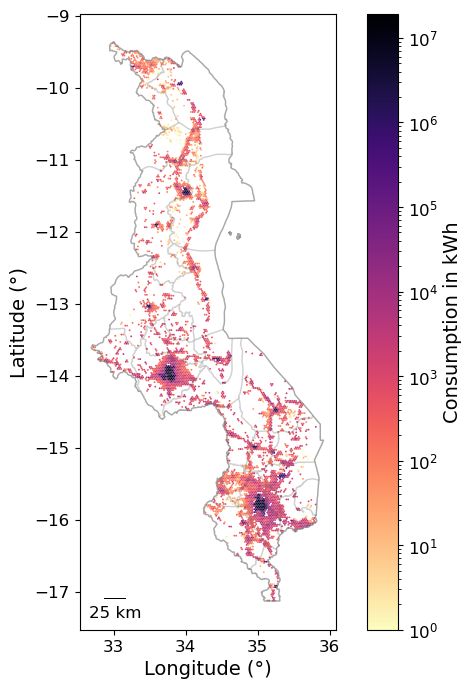

In [85]:
# Plot the demand map with a log scale value
# Create the axis first
fig, ax = plt.subplots(figsize=(8, 8))

# Add latitude and longitude labels
ax.set_xlabel('Longitude (°)', fontsize=14)
ax.set_ylabel('Latitude (°)', fontsize=14)
ax.tick_params(axis='both', labelsize=12)

# Plot data
grid.sort_values('REnS_kWh', ascending=True).plot(
    ax=ax, column='REnS_kWh', cmap="magma_r", legend=True, alpha=1, norm=colors.LogNorm(vmin = 1, vmax=grid['REnS_kWh'].max()),
    ) 

#legend
legend = fig.axes[1] 
legend.tick_params(labelsize=12)
legend.set_ylabel("Consumption in kWh", fontsize=14)  # Add a label to the colorbar

admin_gdf.plot(ax=ax, edgecolor='grey', color='None', alpha=0.6)
region_gdf.plot(ax=ax, edgecolor='grey', color='None', alpha=0.2)
# transmission lines
#lines_gdf.plot(ax=ax, edgecolor='darkblue', color='darkblue', alpha=0.75, linewidth=2)
#lines_132.plot(ax=ax, edgecolor='darkblue', color='darkblue', alpha=0.5, linewidth=1.5)

ax.set_aspect('equal', 'box')
# txt = ax.set_title('Electricity consumption in the residential sector in {} (kWh)'.format(area) )
# txt = ax.set_title('Electricity consumption in the residential sector (kWh)' )

# print(grid.crs)

# Compute the distance-per-pixel of the map
# see https://geopandas.org/en/latest/gallery/matplotlib_scalebar.html#Geographic-coordinate-system-(degrees)
# assert grid.crs == 'EPSG:4326'
from shapely.geometry.point import Point
points = gpd.GeoSeries(
    [Point(-73.5, 40.5), Point(-74.5, 40.5)], crs=4326
)  # Geographic WGS 84 - degrees
points = points.to_crs(32619)  # Projected WGS 84 - meters
distance_meters = points[0].distance(points[1])

# Add a scale bar
scalebar = ScaleBar(
    distance_meters,
    dimension="si-length",
    location='lower left',
    length_fraction=0.1,
    width_fraction=0.001,
    units='m',
    color='black',
    fixed_value=None,
    font_properties={"size": 12}
)

ax.add_artist(scalebar)

# Save plot as figure 
plt.savefig(out_path +'map_residential_log.png', bbox_inches='tight', dpi=300)

### Services map

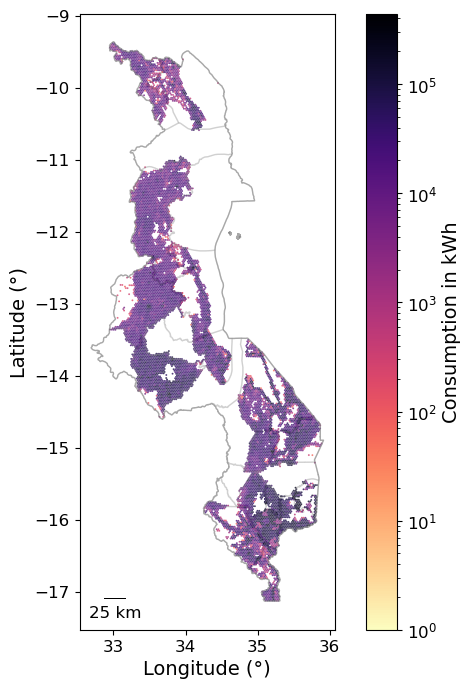

In [87]:
## Plot the demand map with a log scale value
# Create the axis first
fig, ax = plt.subplots(figsize=(8, 8))
# Add latitude and longitude labels
ax.set_xlabel('Longitude (°)', fontsize=14)
ax.set_ylabel('Latitude (°)', fontsize=14)
ax.tick_params(axis='both', labelsize=12)


# Plot data
grid.sort_values('SEn_kWh', ascending=True).plot(
    ax=ax, column='SEn_kWh', cmap="magma_r", legend=True, alpha=0.8, norm=colors.LogNorm(vmin = 1, vmax=grid['SEn_kWh'].max()))

#legend
legend = fig.axes[1] 
legend.tick_params(labelsize=12)
legend.set_ylabel("Consumption in kWh", fontsize=14)  # Add a label to the colorbar

admin_gdf.plot(ax=ax, edgecolor='grey', color='None', alpha=0.6)
region_gdf.plot(ax=ax, edgecolor='grey', color='None', alpha=0.2)
# transmission lines
#lines_gdf.plot(ax=ax, edgecolor='darkblue', color='darkblue', alpha=0.75, linewidth=2)
#lines_132.plot(ax=ax, edgecolor='darkblue', color='darkblue', alpha=0.5, linewidth=1.5)

# # Plot data
# grid.sort_values('TotalDem', ascending=True).plot(
#     ax=ax, column='TotalDem', cmap="Reds", legend=True, alpha=0.5, vmin=0, vmax=threshold)

# # Plot data
# grid.sort_values('TotalDem', ascending=True).plot(
#     ax=ax, column='TotalDem', cmap="Reds", legend=True, alpha=0.9)

# Compute the distance-per-pixel of the map
# see https://geopandas.org/en/latest/gallery/matplotlib_scalebar.html#Geographic-coordinate-system-(degrees)
# assert grid.crs == 'EPSG:4326'
from shapely.geometry.point import Point
points = gpd.GeoSeries(
    [Point(-73.5, 40.5), Point(-74.5, 40.5)], crs=4326
)  # Geographic WGS 84 - degrees
points = points.to_crs(32619)  # Projected WGS 84 - meters
distance_meters = points[0].distance(points[1])

# Add a scale bar
scalebar = ScaleBar(
    distance_meters,
    dimension="si-length",
    location='lower left',
    length_fraction=0.1,
    width_fraction=0.001,
    units='m',
    color='black',
    fixed_value=None,
    font_properties={"size": 12}
)
ax.set_aspect('equal', 'box')
# txt = ax.set_title('Electricity in the services sector in {} (kWh)'.format(area) )
# txt = ax.set_title('Electricity in the services sector (GWh)')

ax.add_artist(scalebar)
# Save plot as figure 
plt.savefig(out_path +'map_services_log.png', bbox_inches='tight', dpi=300)

### Buildings map

In [42]:
grid['Bui_GWh'] = grid['SEn_GWh']+grid['REnS_GWh']
grid['Bui_kWh'] = grid['SEn_kWh']+grid['REnS_kWh']

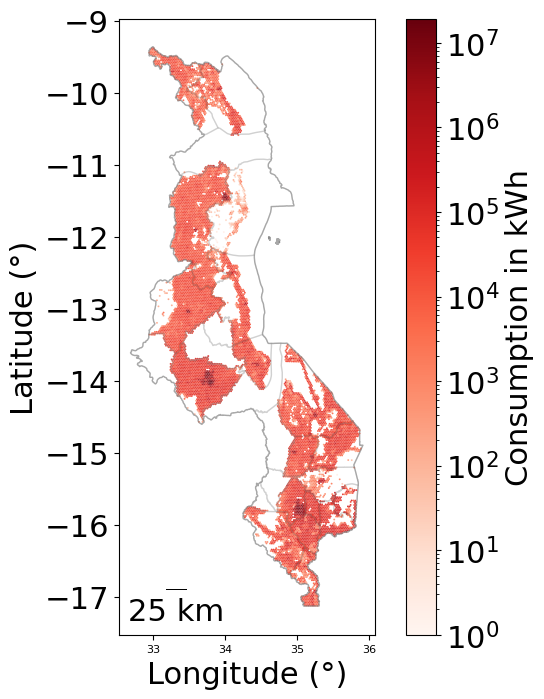

In [44]:
# Plot the demand map with a log scale value
# Create the axis first
# sns.set_theme('poster')
# sns.set_style('white')
fig, ax = plt.subplots(figsize=(8, 8))
# Add latitude and longitude labels
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')


# Plot data
grid.sort_values('Bui_kWh', ascending=True).plot(
    ax=ax, column='Bui_kWh', cmap="Reds", legend=True, alpha=0.9, norm=colors.LogNorm(vmin = 1, vmax=grid['Bui_kWh'].max()),
    legend_kwds={"label": "Consumption in kWh"})
admin_gdf.plot(ax=ax, edgecolor='grey', color='None', alpha=0.6)
region_gdf.plot(ax=ax, edgecolor='grey', color='None', alpha=0.2)
# transmission lines
#lines_gdf.plot(ax=ax, edgecolor='darkblue', color='darkblue', alpha=0.75, linewidth=2)
#lines_132.plot(ax=ax, edgecolor='darkblue', color='darkblue', alpha=0.5, linewidth=1.5)

# Compute the distance-per-pixel of the map
# see https://geopandas.org/en/latest/gallery/matplotlib_scalebar.html#Geographic-coordinate-system-(degrees)
# assert grid.crs == 'EPSG:4326'
from shapely.geometry.point import Point
points = gpd.GeoSeries(
    [Point(-73.5, 40.5), Point(-74.5, 40.5)], crs=4326
)  # Geographic WGS 84 - degrees
points = points.to_crs(32619)  # Projected WGS 84 - meters
distance_meters = points[0].distance(points[1])

# Add a scale bar
scalebar = ScaleBar(
    distance_meters,
    dimension="si-length",
    location='lower left',
    length_fraction=0.1,
    width_fraction=0.001,
    units='m',
    color='black',
    fixed_value=None
)
ax.set_aspect('equal', 'box')
# txt = ax.set_title('Electricity in buildings in {} (kWh)'.format(area) )
# txt = ax.set_title('Electricity in buildings (GWh)')

ax.add_artist(scalebar)
# Save plot as figure 
plt.savefig(out_path +'map_buildings_log.png', bbox_inches='tight')

### Industry map

In [61]:
# # Plot the industry demand map per cell
# # Create the axis first
# fig, ax = plt.subplots(figsize=(25, 15))

# # Plot data with a log scale value
# grid.sort_values('IndEnergy_kWh', ascending=True).plot(
#     ax=ax, column='IndEnergy_kWh', cmap="Reds", legend=True, alpha=0.9, norm=colors.LogNorm(vmin = 1, vmax=grid['IndEnergy_kWh'].max()),
#     legend_kwds={"label": "Consumption in kWh"})

# # # Plot data
# # grid.sort_values('IndEnergy_GWh', ascending=True).plot(
# #     ax=ax, column='IndEnergy_GWh', cmap="Reds", legend=True, alpha=0.5, vmin=0, vmax=threshold)

# # # Plot data
# # grid.sort_values('IndEnergy_GWh', ascending=True).plot(
# #     ax=ax, column='IndEnergy_GWh', cmap="Reds", legend=True, alpha=0.9)

# admin_gdf.plot(ax=ax, edgecolor='brown', color='None', alpha=0.6)
# region_gdf.plot(ax=ax, edgecolor='brown', color='None', alpha=0.2)
# # lines_gdf.plot(ax=ax, edgecolor='brown', alpha=0.2)

# # Compute the distance-per-pixel of the map
# # see https://geopandas.org/en/latest/gallery/matplotlib_scalebar.html#Geographic-coordinate-system-(degrees)
# # assert grid.crs == 'EPSG:4326'
# from shapely.geometry.point import Point
# points = gpd.GeoSeries(
#     [Point(-73.5, 40.5), Point(-74.5, 40.5)], crs=4326
# )  # Geographic WGS 84 - degrees
# points = points.to_crs(32619)  # Projected WGS 84 - meters
# distance_meters = points[0].distance(points[1])

# # Add a scale bar
# scalebar = ScaleBar(
#     distance_meters,
#     dimension="si-length",
#     location='lower left',
#     length_fraction=0.1,
#     width_fraction=0.001,
#     units='m',
#     color='black',
#     fixed_value=None
# )

# ax.set_aspect('equal', 'box')
# # txt = ax.set_title('Electricity in the mining sector in {} (GWh)'.format(area) )
# ax.add_artist(scalebar)
# # Save plot as figure 
# plt.savefig(out_path +'map_industry_log.png', bbox_inches='tight')

In [62]:
#(grid['IndEnergy_GWh'] != 0).sum()

In [63]:
#(grid['IndEnergy_GWh'] > 50).sum()

In [64]:
# totalperregion=grid.groupby('NAME_1')['IndEnergy_GWh'].sum()
# totalperregion

In [65]:
#grid['totalindeperregion'] = grid['NAME_1'].map(totalperregion)

In [66]:
# # Plot the demand map with a log scale value
# # Create the axis first
# fig, ax = plt.subplots(figsize=(25, 15))

# # Plot data
# grid.sort_values('totalindeperregion', ascending=True).plot(
#     ax=ax, column='totalindeperregion', cmap="Reds", legend=True, alpha=0.9, norm=colors.LogNorm(vmin = 1, vmax=grid['totalindeperregion'].max()))

# # # Plot data
# # grid.sort_values('totalindeperregion', ascending=True).plot(
# #     ax=ax, column='totalindeperregion', cmap="Reds", legend=True, alpha=0.5, vmin=0, vmax=threshold)

# # # Plot data
# # grid.sort_values('totalindeperregion', ascending=True).plot(
# #     ax=ax, column='totalindeperregion', cmap="Reds", legend=True, alpha=0.9)
# admin_gdf.plot(ax=ax, edgecolor='brown', alpha=0.05)
# ax.set_aspect('equal', 'box')
# ax.set_title('Electricity in the mining sector in Zambia (GWh)')
# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')

# from matplotlib.ticker import FuncFormatter

# # fmt = lambda x, pos: '{:.1%}'.format(x)
# # cbar = plt.colorbar(format=FuncFormatter(fmt))

# # Save plot as figure 
# plt.savefig(out_path +'map_log_ind.png', bbox_inches='tight')